In [54]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [55]:
x,y = make_moons(n_samples=1000, noise=0.1, random_state=42)

<Axes: >

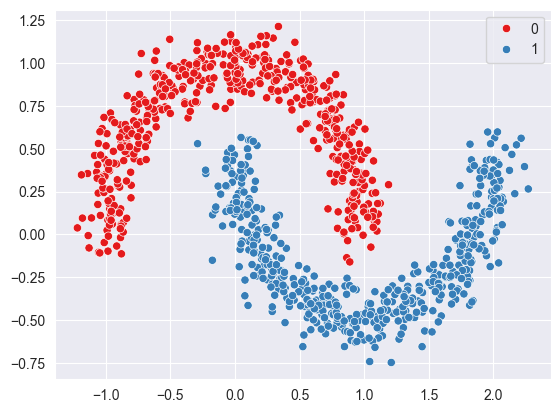

In [56]:
import seaborn as sns
sns.set_style('darkgrid')
sns.scatterplot(x=x[:,0], y=x[:,1], hue=y, palette='Set1')

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [58]:
from keras.models import Sequential
from keras.layers import Dense

In [59]:
model = Sequential([
    Dense(10, activation='tanh', input_shape=(2,)),
    Dense(10, activation='tanh'),
    Dense(1, activation='sigmoid')
])

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
initial_weights = model.get_weights()

In [62]:
for i in range(len(initial_weights)):
    initial_weights[i] = np.random.randn(*initial_weights[i].shape) * np.sqrt(1 / initial_weights[i].shape[0])

In [63]:
initial_weights[0]

array([[-1.36772336, -0.35767603, -0.63171422,  0.09189672,  0.48197963,
        -0.17041418, -0.3678394 ,  1.1184102 ,  0.09145773,  1.00768955],
       [ 0.53050865, -0.16613355,  0.2490243 ,  0.12153429, -0.02783784,
        -0.83638078,  0.19482869,  0.15782706,  0.14810901,  1.33779927]])

In [64]:
model.set_weights(initial_weights)

In [65]:
model.get_weights()

[array([[-1.3677233 , -0.35767603, -0.6317142 ,  0.09189672,  0.48197964,
         -0.17041418, -0.3678394 ,  1.1184102 ,  0.09145773,  1.0076896 ],
        [ 0.53050864, -0.16613355,  0.2490243 ,  0.1215343 , -0.02783784,
         -0.8363808 ,  0.19482869,  0.15782706,  0.148109  ,  1.3377993 ]],
       dtype=float32),
 array([ 0.06876148,  0.05883833, -0.2186454 , -0.05236783,  0.14533515,
        -0.35507694,  0.12903161,  0.50155276, -0.2846701 ,  0.28585047],
       dtype=float32),
 array([[-0.30472034,  0.0440614 , -0.5442571 ,  0.11102507, -0.07753424,
          0.40792167, -0.18308055,  0.31075644,  0.10836504, -0.09860973],
        [ 0.31206018,  0.71750355,  0.5532536 ,  0.04985666,  0.20667021,
          0.38813397, -0.4194619 ,  0.54427457,  0.13254938,  0.19377513],
        [ 0.09795076, -0.3987645 , -0.22311355,  0.17661496,  0.32233107,
          0.41628635,  0.4365018 , -0.31146035, -0.1283122 , -0.24596123],
        [-0.20064196, -0.09416984,  0.15155946,  0.06594304, 

In [66]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3219 - loss: 0.7365 - val_accuracy: 0.4062 - val_loss: 0.7029
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6328 - loss: 0.6776 - val_accuracy: 0.8000 - val_loss: 0.6466
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8172 - loss: 0.6252 - val_accuracy: 0.8375 - val_loss: 0.5954
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.5752 - val_accuracy: 0.8250 - val_loss: 0.5493
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8141 - loss: 0.5303 - val_accuracy: 0.7875 - val_loss: 0.5070
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8078 - loss: 0.4891 - val_accuracy: 0.7937 - val_loss: 0.4707
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8094 - loss: 0.4547 - val_accuracy: 0.8062 - val_loss: 0.4393
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8188 - loss: 0.4251 - val_accuracy: 0.8250 - val_loss: 0.

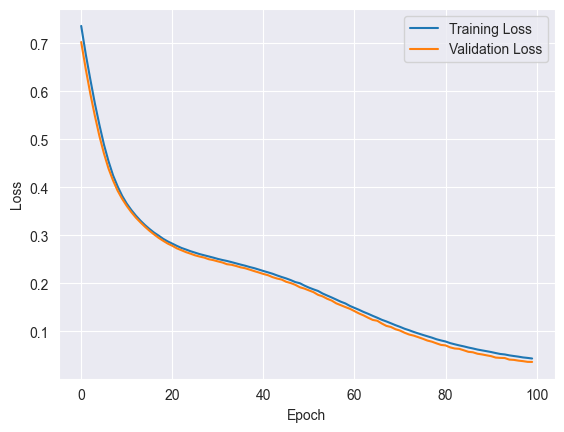

In [67]:
import seaborn as sns
sns.set_style('darkgrid')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 734us/step


<Axes: >

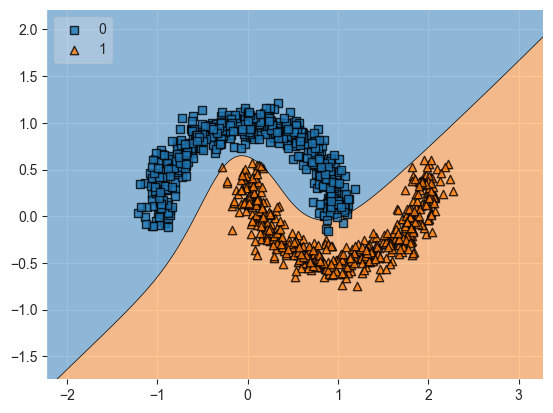

In [68]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x, y, clf=model, legend=2)

In [74]:
initial_weights[1].shape[0]

10